In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult", "old_adult"],
    "../data/",
)

# Usa House

# Effects of Different Annonymzation Models

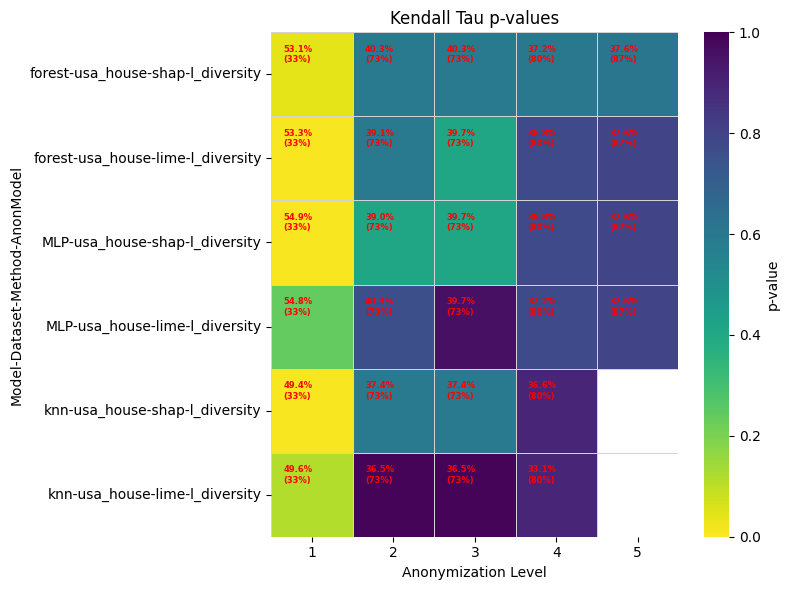

In [9]:
pl.plot_heatmap(datasets=["usa_house"], methods=['l_diversity'])

Note, for l_diversity knn, no important features were found fo l=5. Also note, that the dataset must be be generalized a lot to reach l=3. Indicating that the anonymization models are expensive to impose on the dataset.

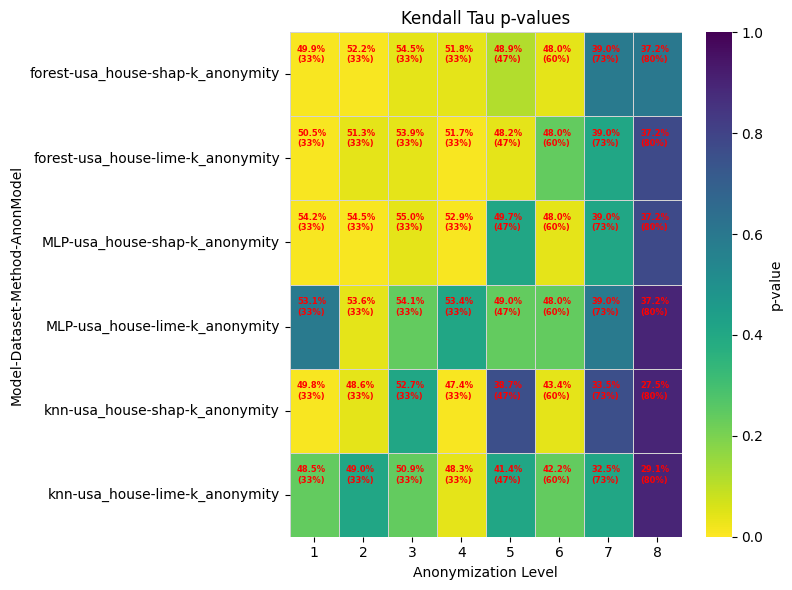

In [10]:
pl.plot_heatmap(datasets=["usa_house"], methods=['k_anonymity'])

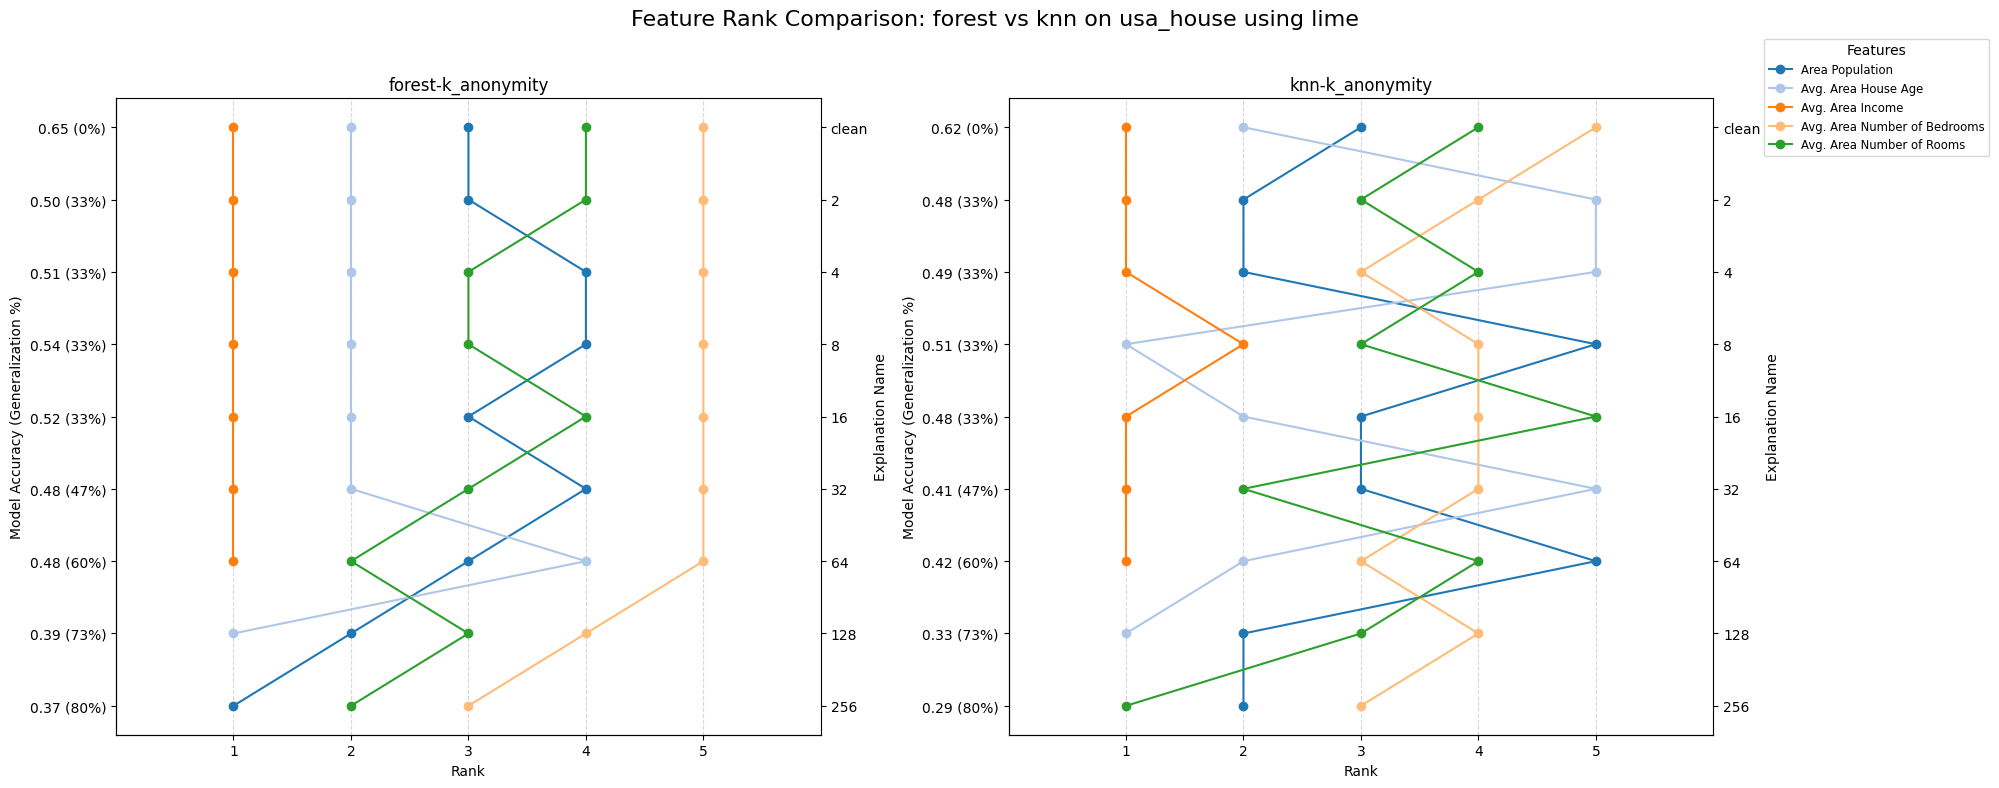

In [5]:
pl.plot_line_compare("forest","knn","usa_house","lime","k_anonymity")

Here we see that knn also shows signs of instability. It is weird though, because it has not been this clear before. The stableness is most likely also depend on the data. Some data is described by some models better than others. When the adult dataset has been generalized to this exact level, the model might do worse at explaining the data. Also, wee see that the accuracy is quite unstable. MLP has a more consistent accuracy

## Unstableness of MLP

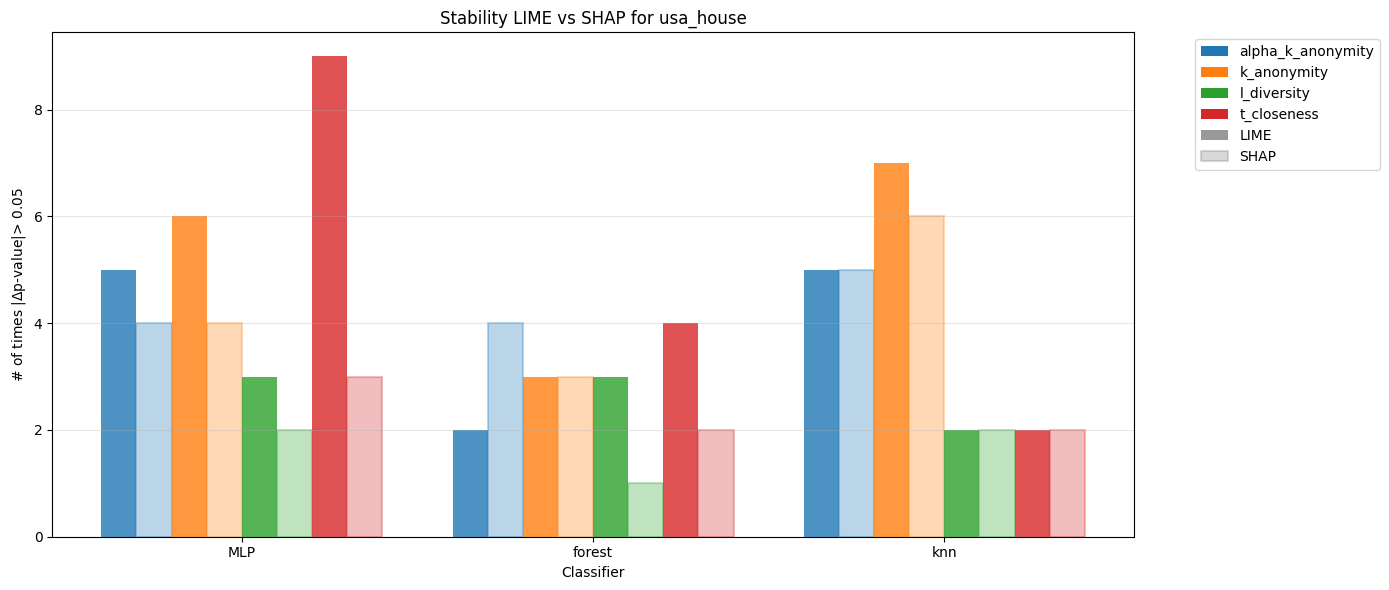

In [19]:
pl.plot_histogram("usa_house", threshold=0.05)

The above histogram that LIME generally produces rankings that are more unstable than SHAP. Here the stability is measured by the amount of times the p-value produced by two adjacent dataset har a higher absolute difference than 5%. Why 5%? Becuase it is we usually work with a 95% significance interval. It's is definetly chosen arbitrarily, but it tries to show the amount of times there is a change in the produced p-value. Be carefull with saying that there is a significant difference in the p-values, since no statistic have been made on that. 

What is up with alpha_k_anonymity for forest? Let us check

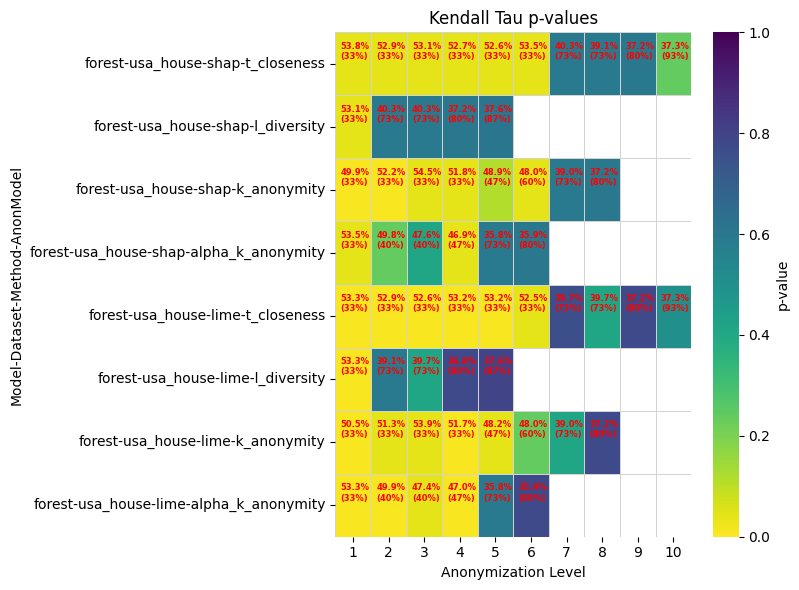

In [4]:
pl.plot_heatmap(classifiers=["forest"], datasets=["usa_house"])

Even the accuracy changes, even though the generalization does not seem to change that much

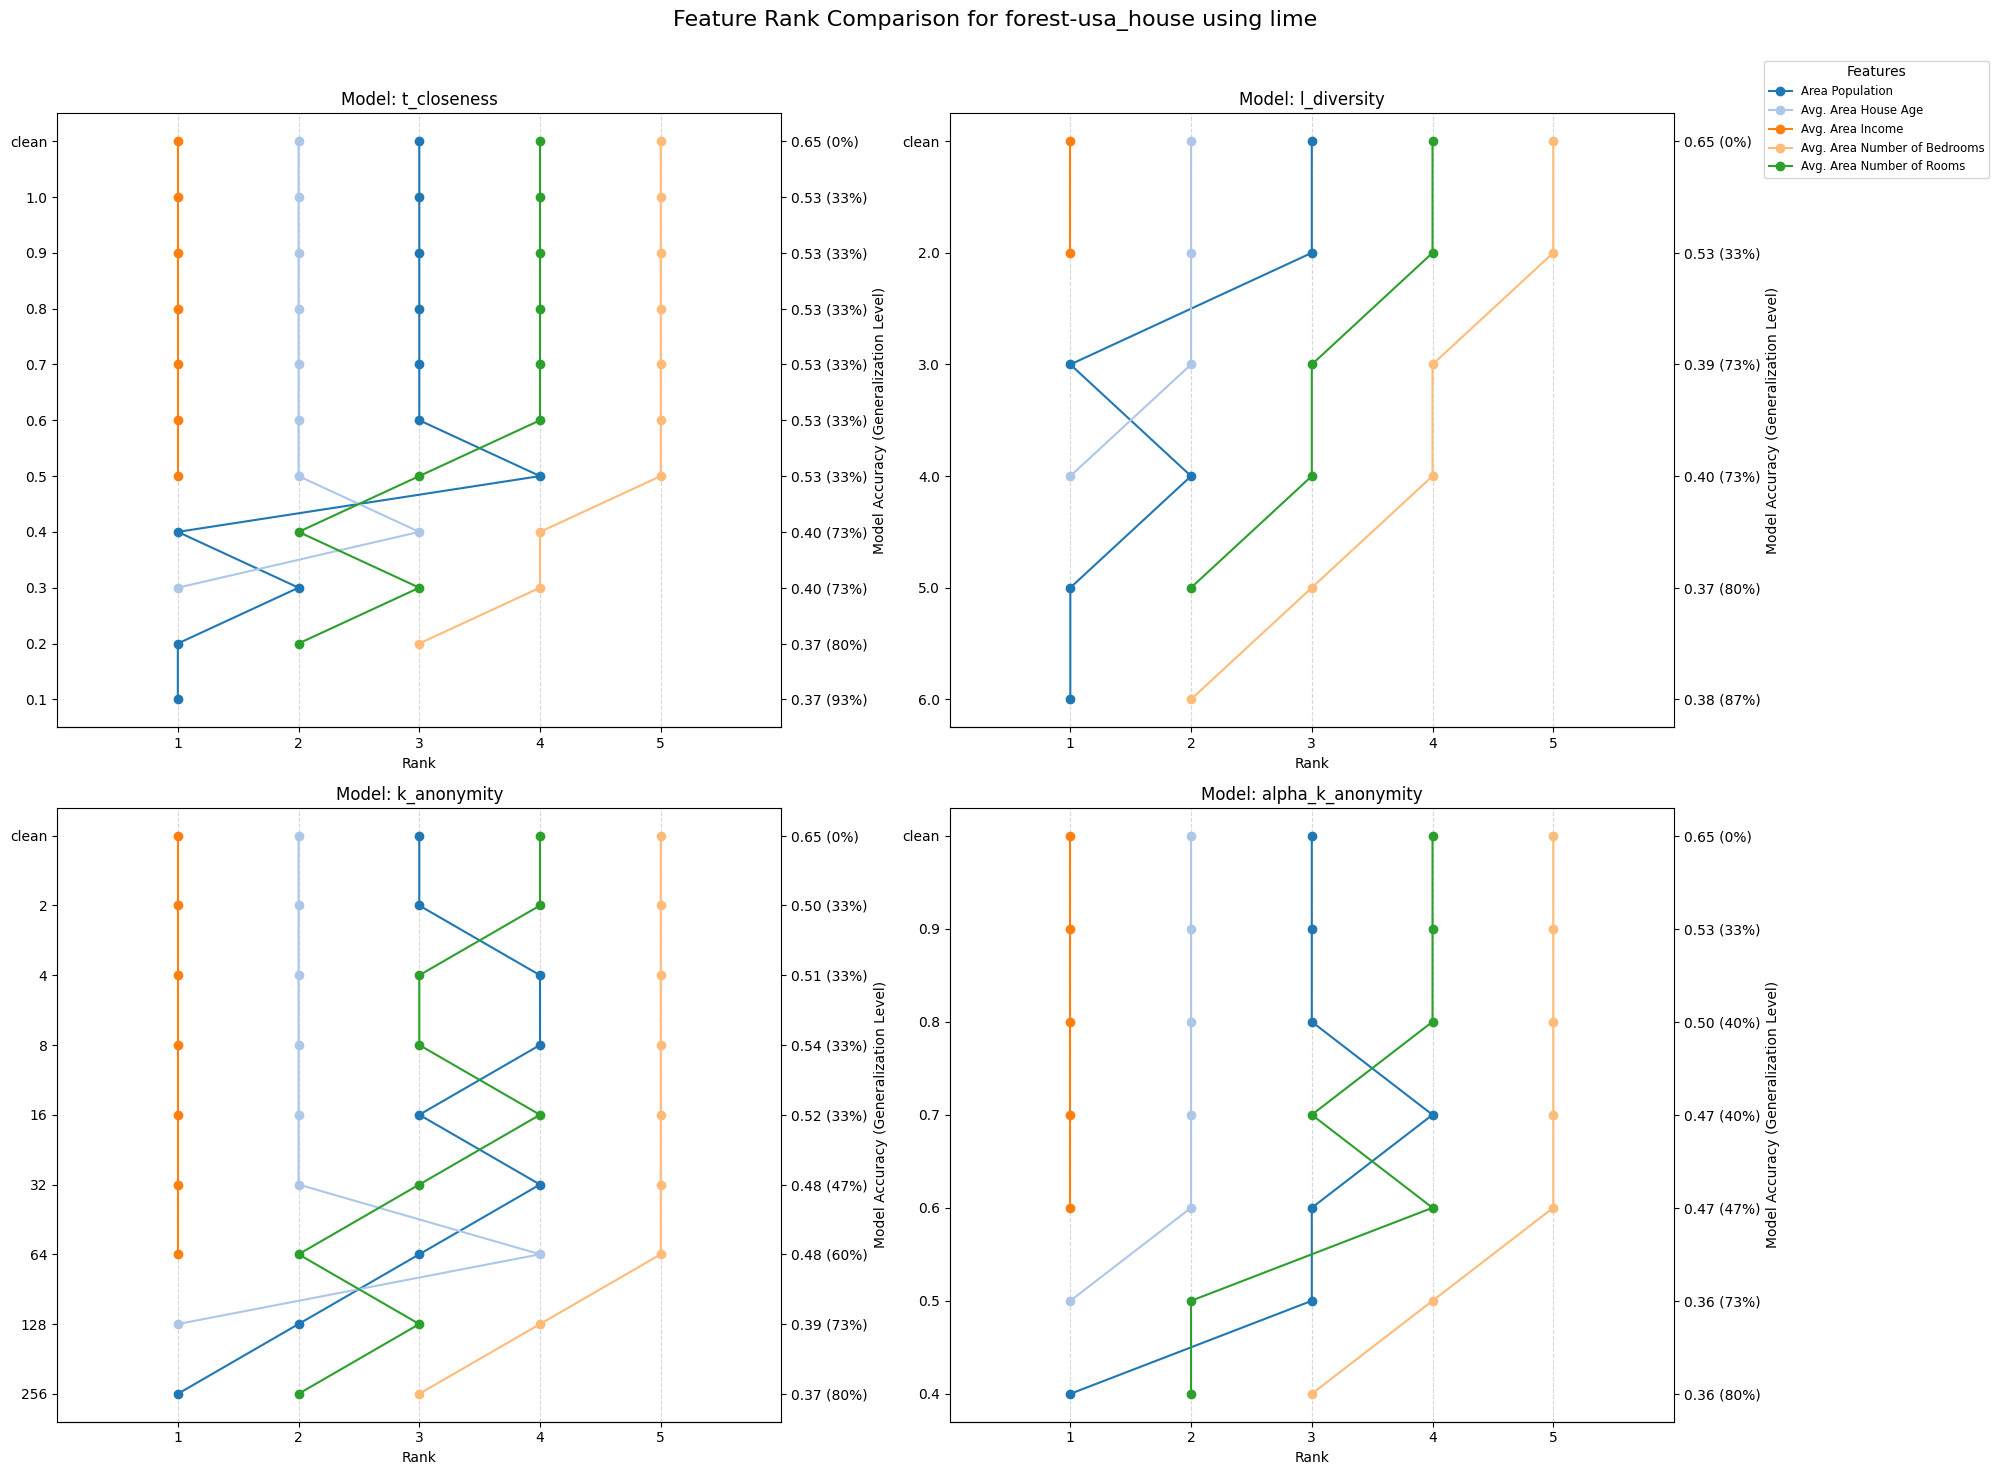

In [21]:
pl.plot_line("forest","usa_house","lime")

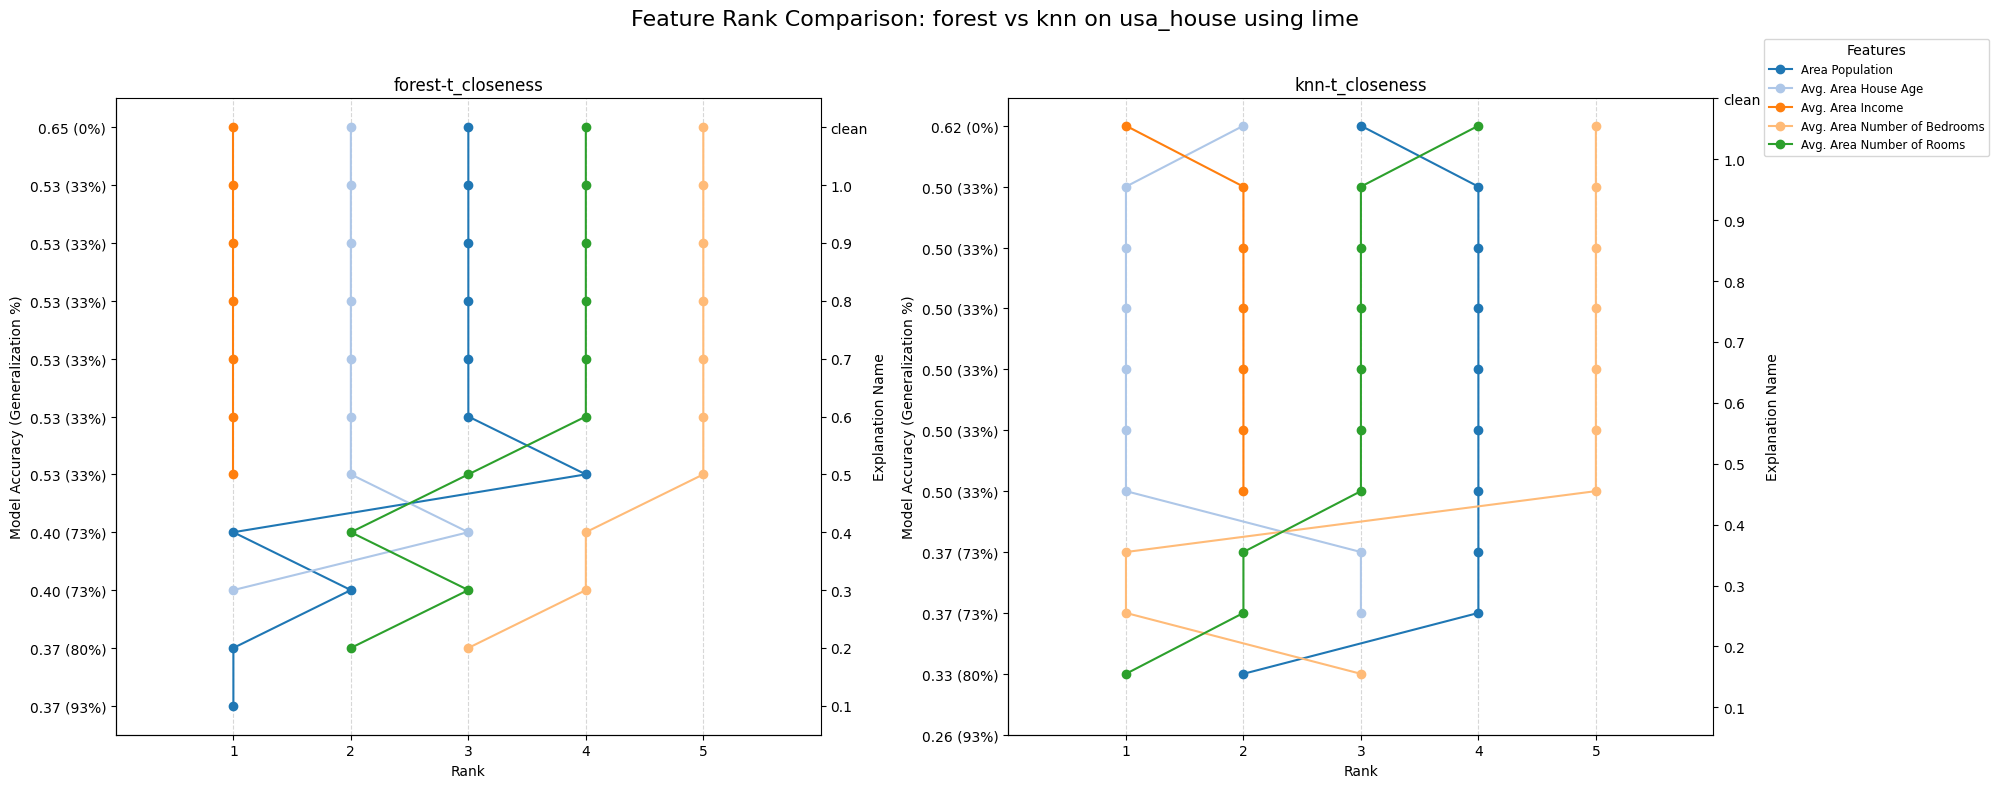

In [10]:
pl.plot_line_compare("forest","knn","usa_house","lime","t_closeness")

Across the two datasets, forest and knn produces stable results! We can also show that for MLP it is more unstable. Look at plots below

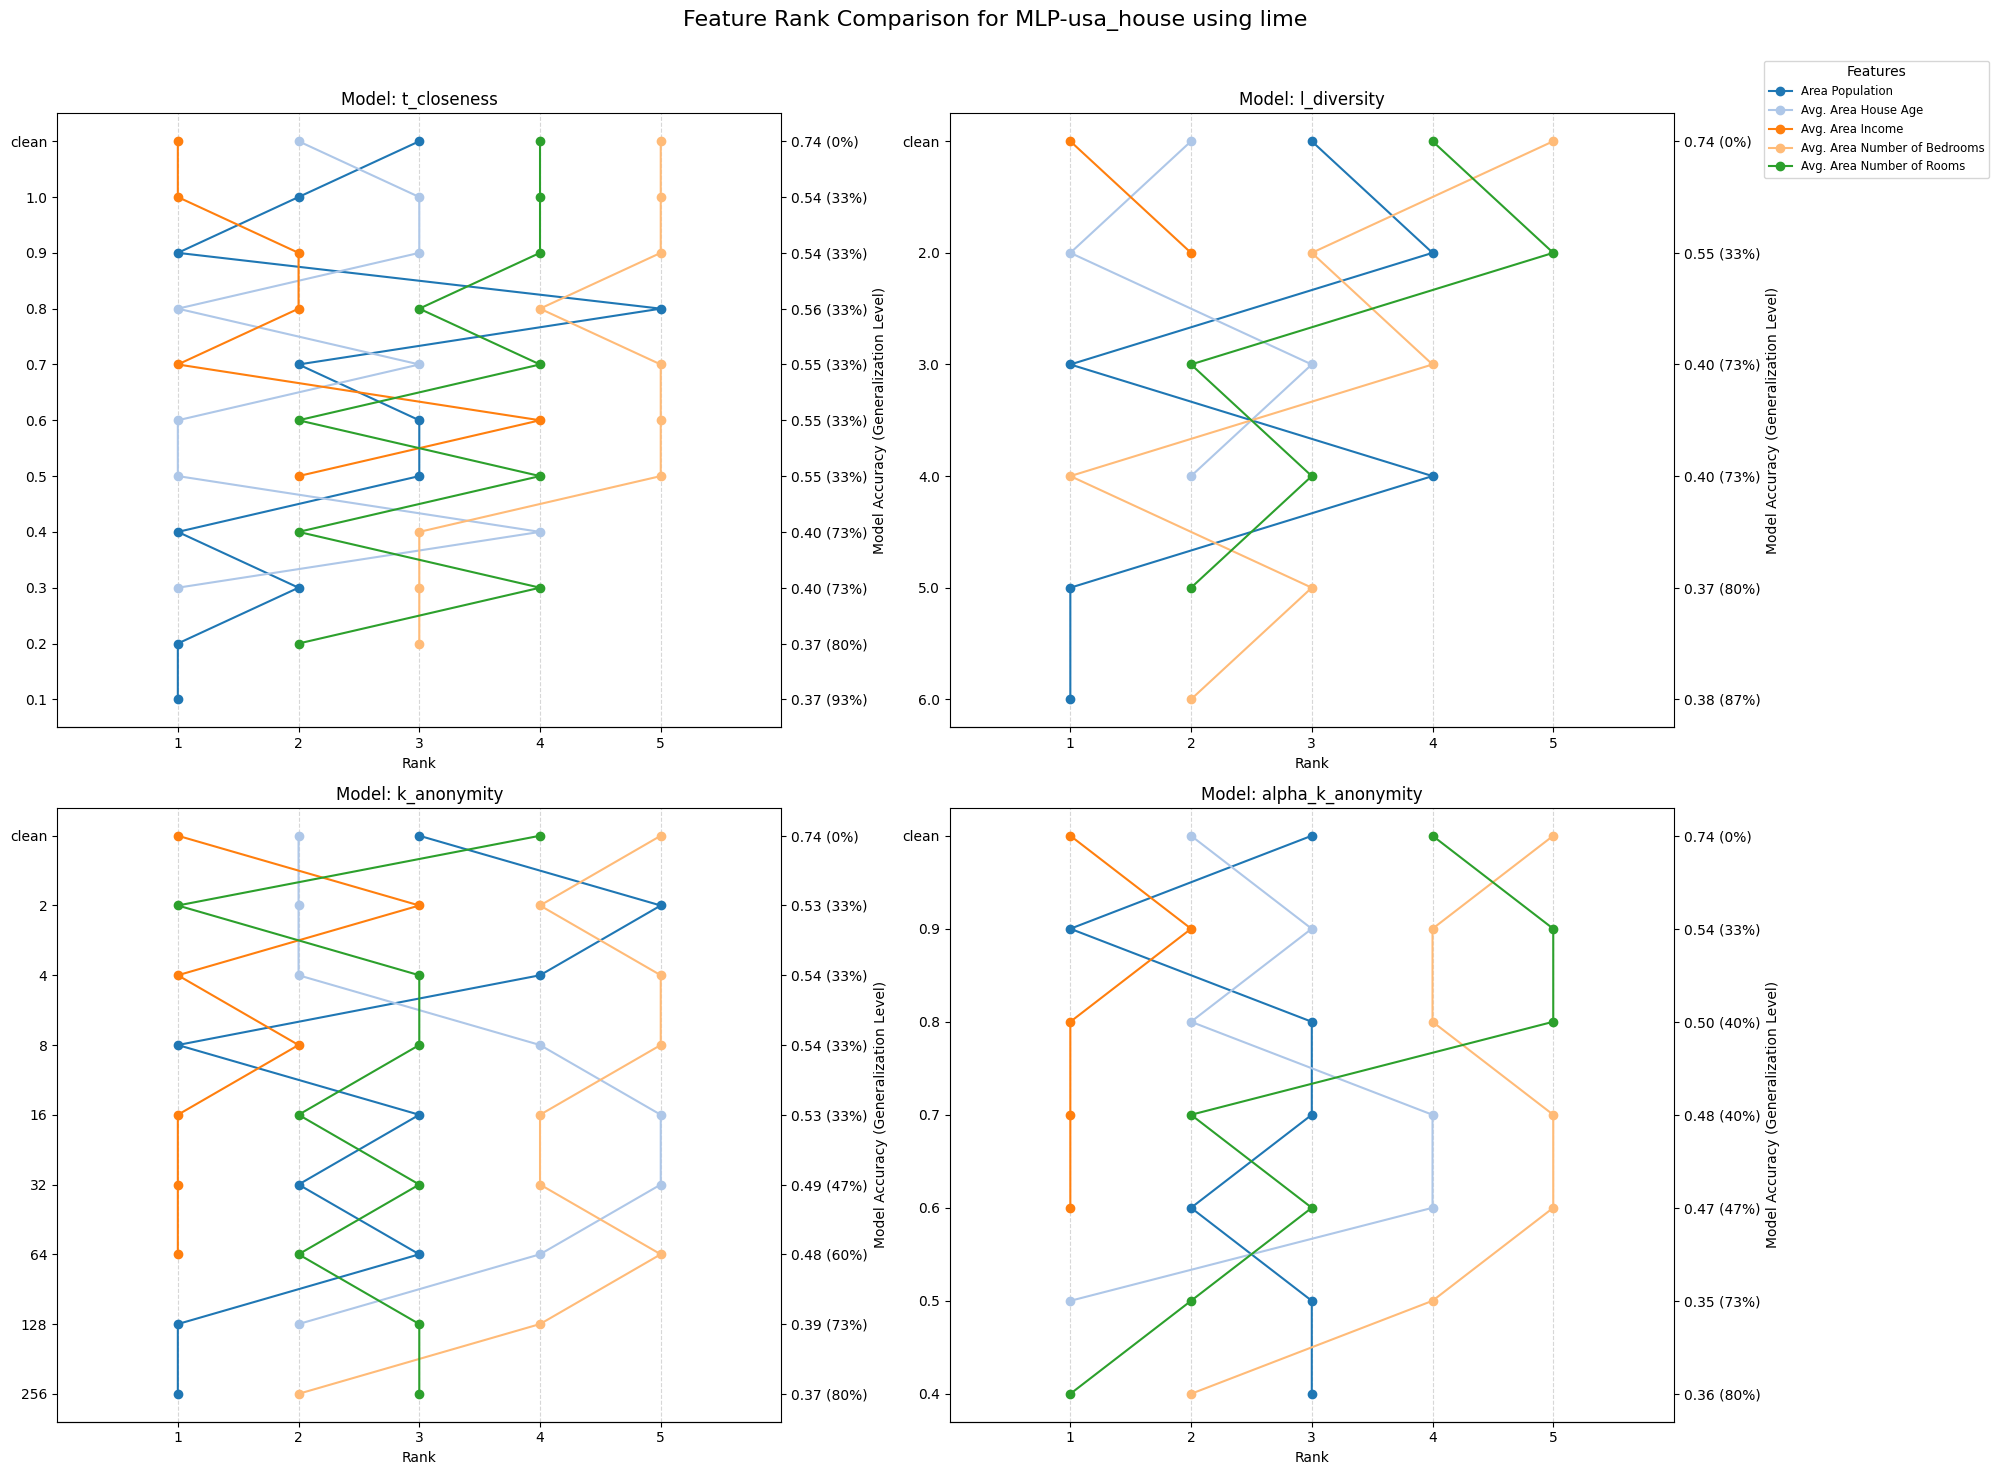

In [11]:
pl.plot_line("MLP","usa_house","lime")

Consider the line plots for the t_closeness plots. We clealy see that MLP is much more unstable for the t_closeness! Sure LIME is model agnostic, but the model has a big impact on it as well.  
Note, that we did not discover this behavior earlier when we were not using scikit learns defaults. There we were using sgd and l2 penalization. So the hyper parameters you choose also has an effect on the lime rankings. That should not be weird, but it is impressive that it can make the lime predictions so unstable

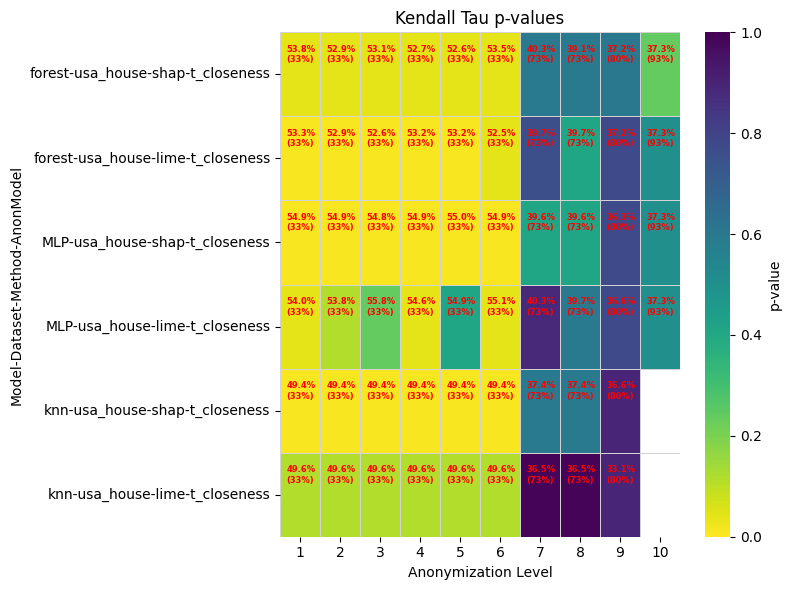

In [12]:
pl.plot_heatmap(datasets=["usa_house"], methods=['t_closeness'])

This plot also shows the unstability of lime. All other produced rankings have low p and constant p-values, but not the MLP lime one. 

# Cervic Cancer

Note this cerviv cancer is the updated one. It has all the features, including the DX features. It has been suppressed to 30% and k=10

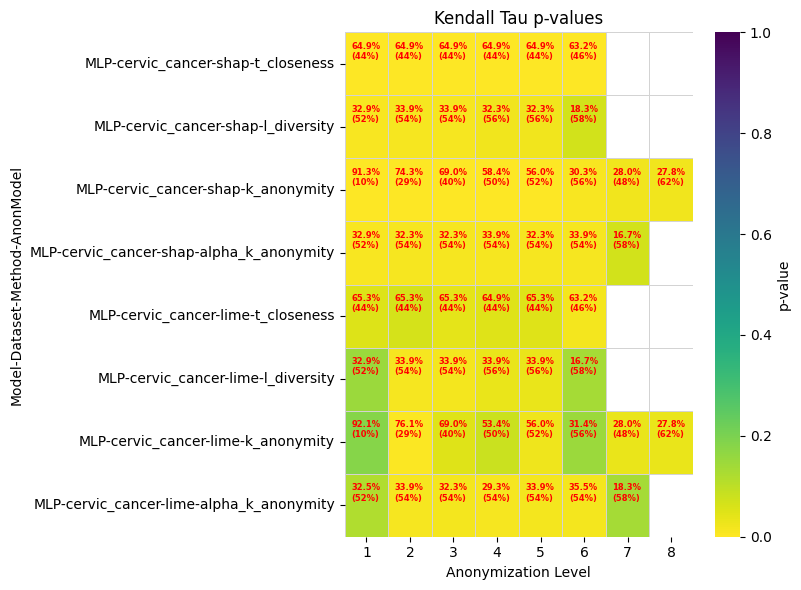

In [3]:
pl.plot_heatmap(datasets=["cervic_cancer"], classifiers=["MLP"])

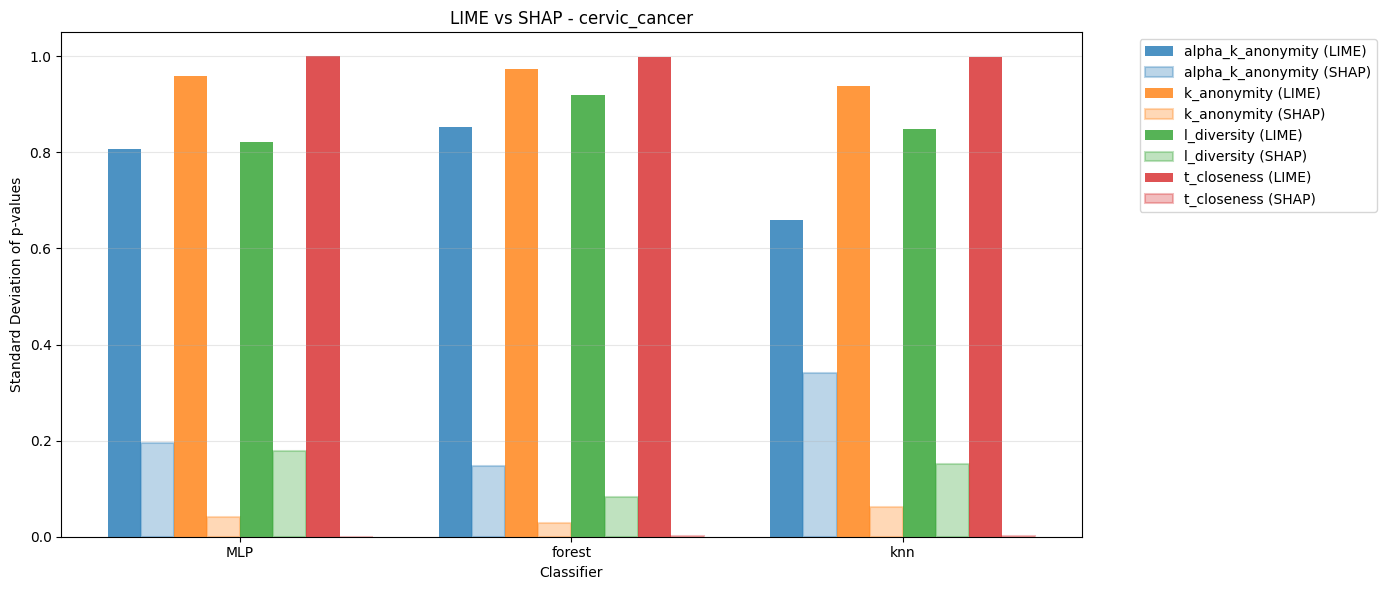

In [5]:
pl.plot_histogram("cervic_cancer")

This histogram perfectly shows that LIME is much more unstable than SHAP. Especially for t_closeness which do not change in generalization that much! It shows that the same dataset produces much more different rankings

Maybe look at some normalized distance? This is the absolute sum of how much the pvalue changes between datasets. High numbers indicate that high instability.  
Bad thing about this plot: If there is one big spike in a ranking between two dataset (because the data set changed alot) and it is the only point where it is unstable, i.e. everywhere else it is constant, then it will dominate the plot. It does show instability to some extent, but I specifically want to show that the same dataset produces the quite different rankings when using LIME compared to using SHAP. Either:
* Select only rankings for dataset that stays the same
* Do not penalize big differences so much

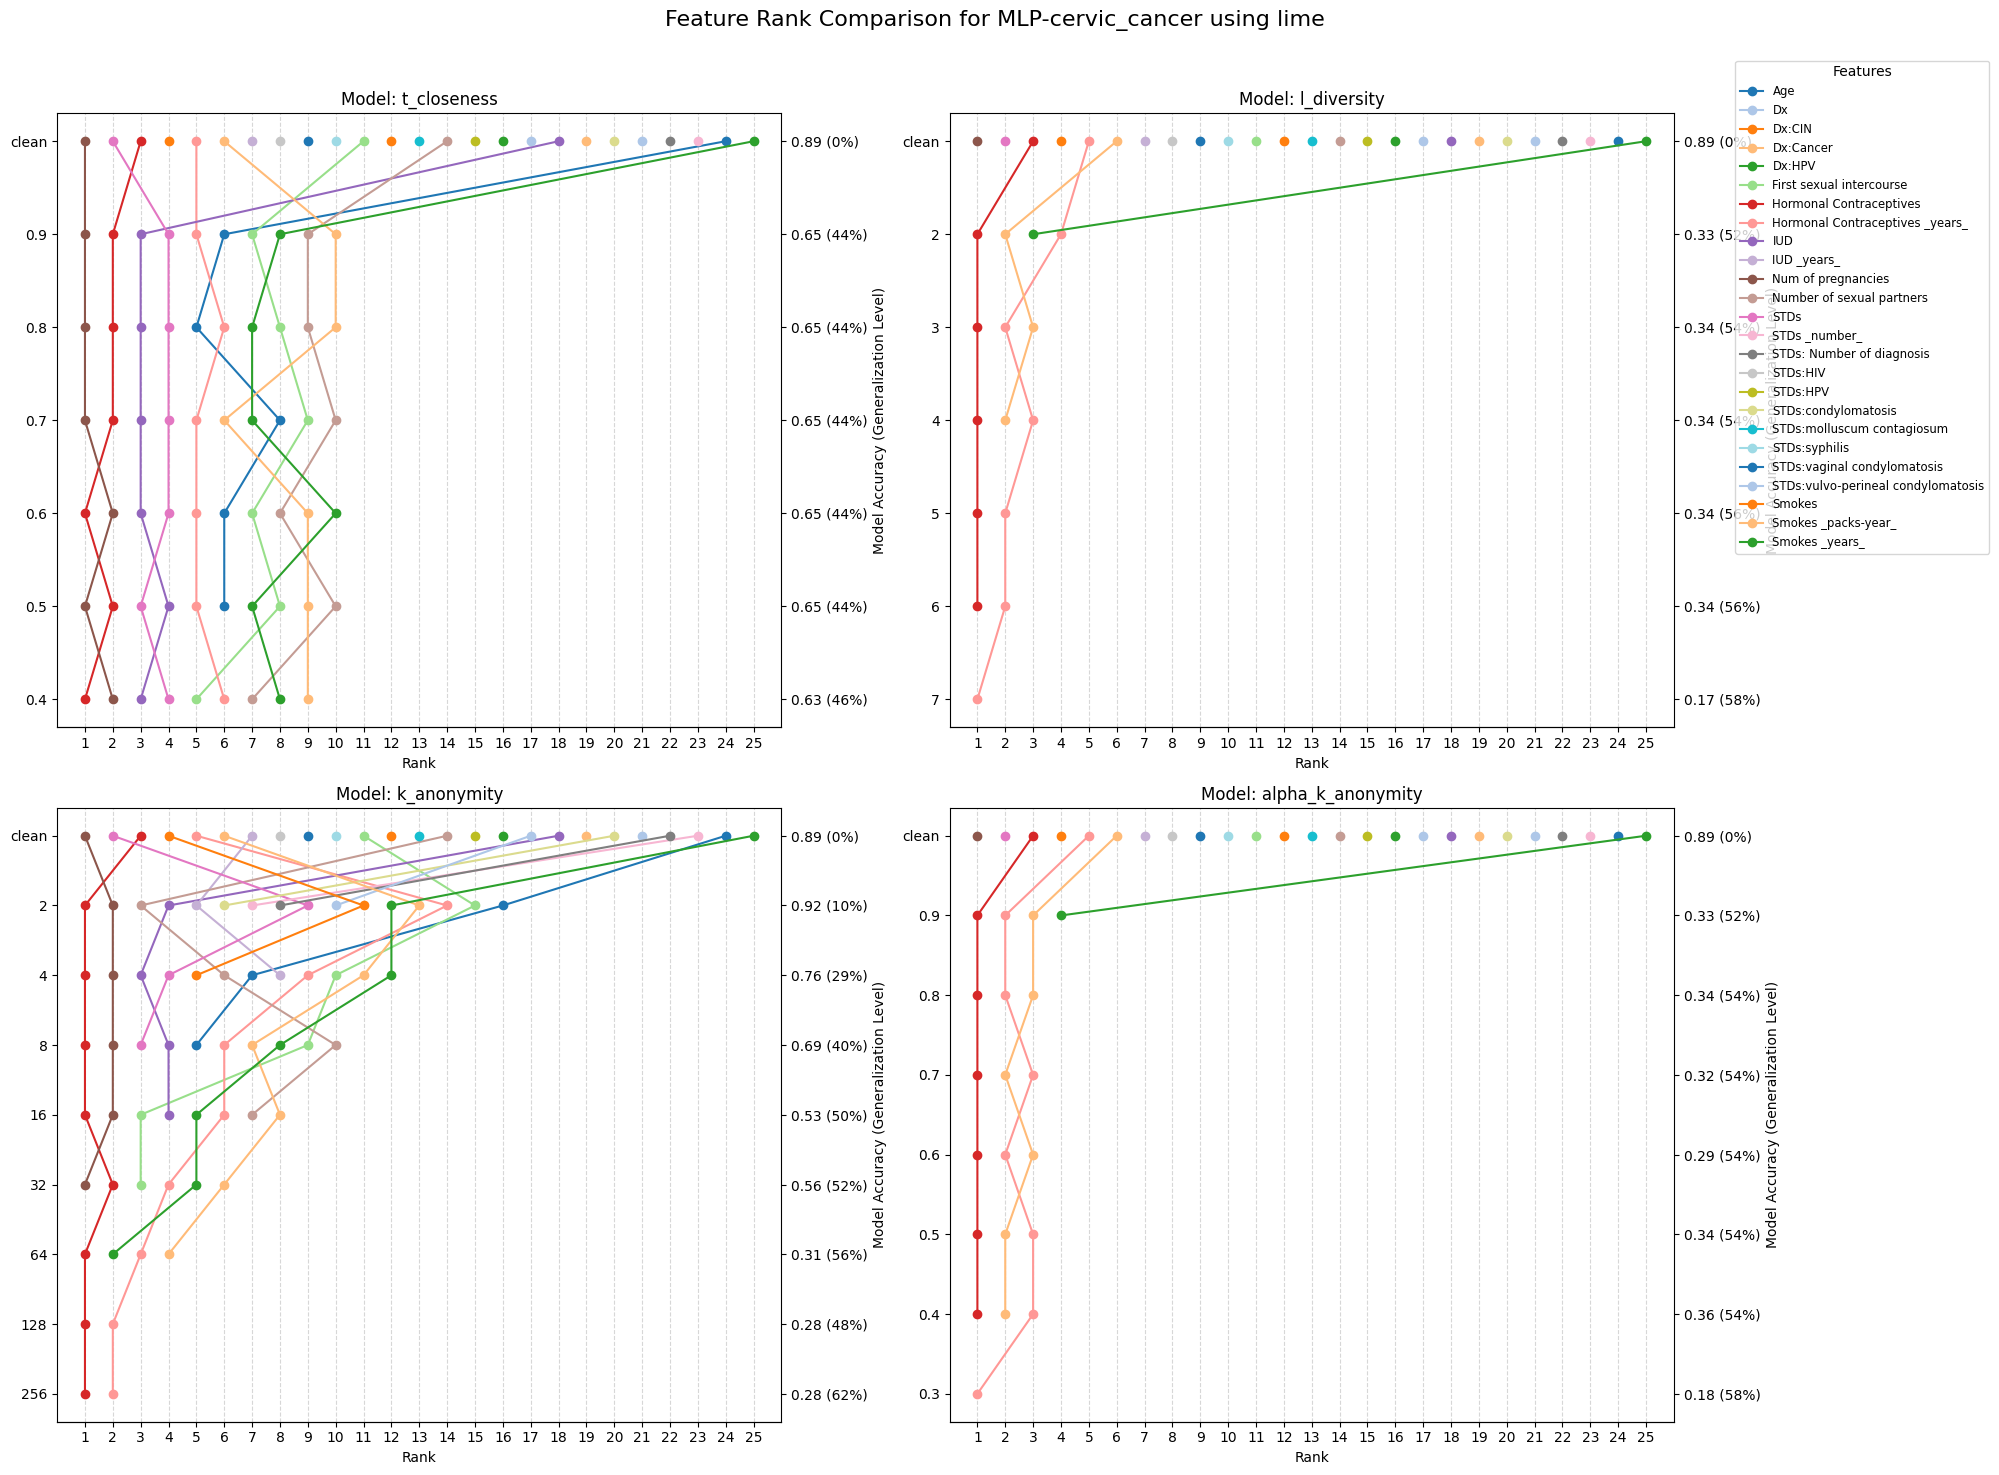

In [15]:
pl.plot_line("MLP", "cervic_cancer", "lime")

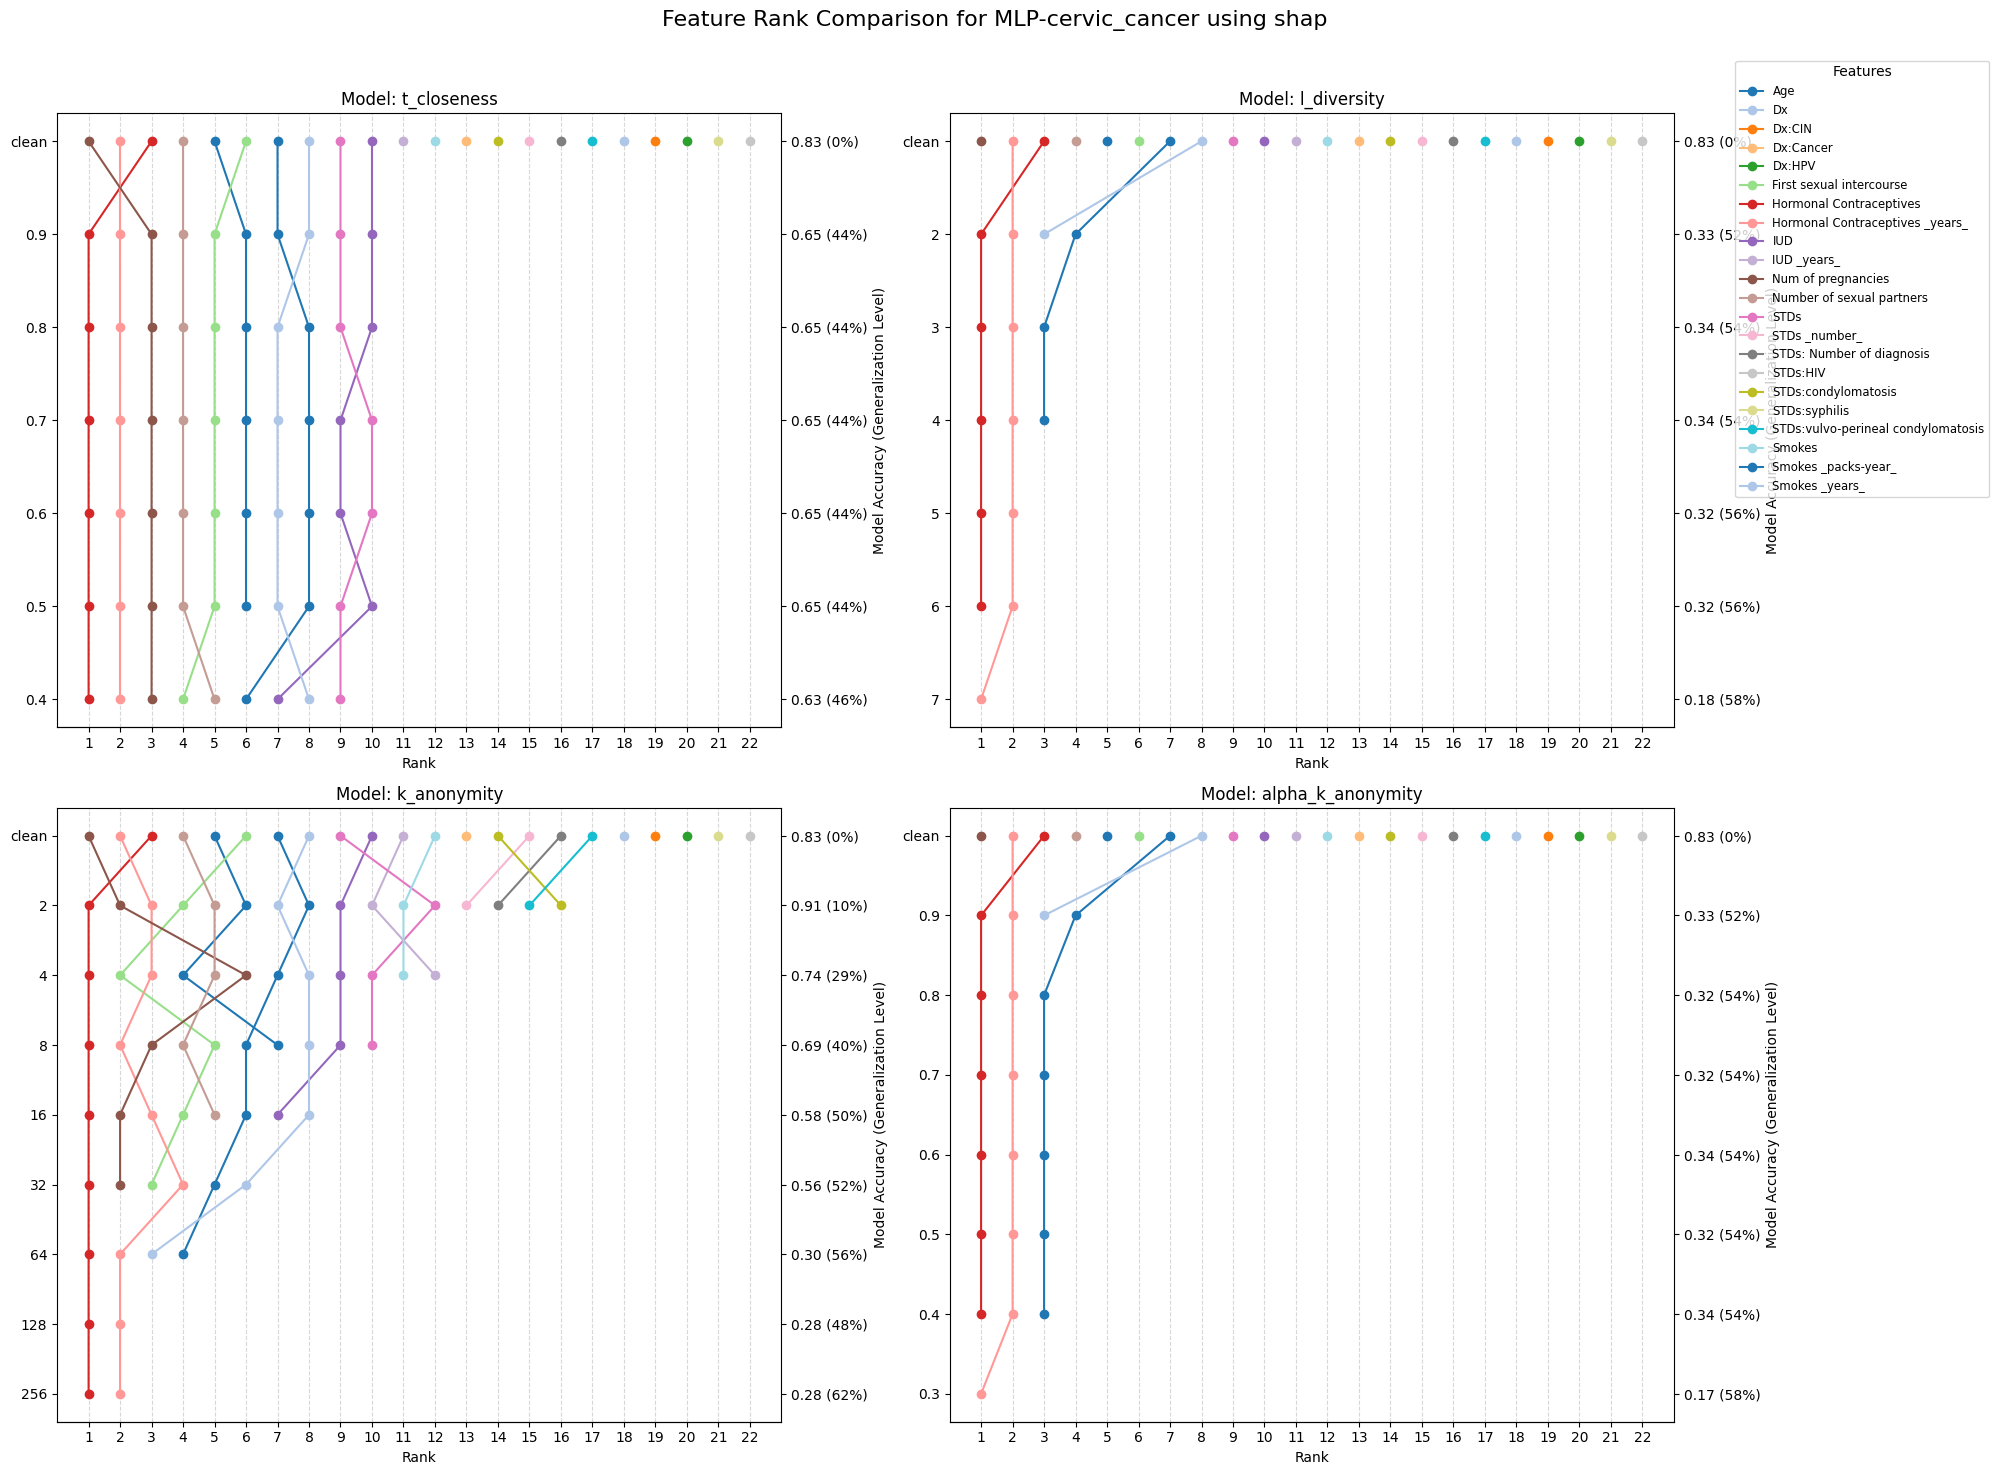

In [16]:
pl.plot_line("MLP", "cervic_cancer", "shap")

Some anonymization models are much harsher on the data than others. l diversity is super difficult imposing. Alose note, the l-diversity and alpha_k_anonymity line plots should looke quite similar, but they do not. Anjana library is fucked and it could generate l_diversity datasets even though alpha_k_anonymity could. Alpha implies l_diversity

Notice how LIME produces an initial ranking where a lot of the features it deems important are anonymized away straight away. This might be Coincidence, since the features that are kept are just the featuers appear later in the dataframe. Again showing that hiearchy and how you apply them has a huge impact

## Comparing Classifiers

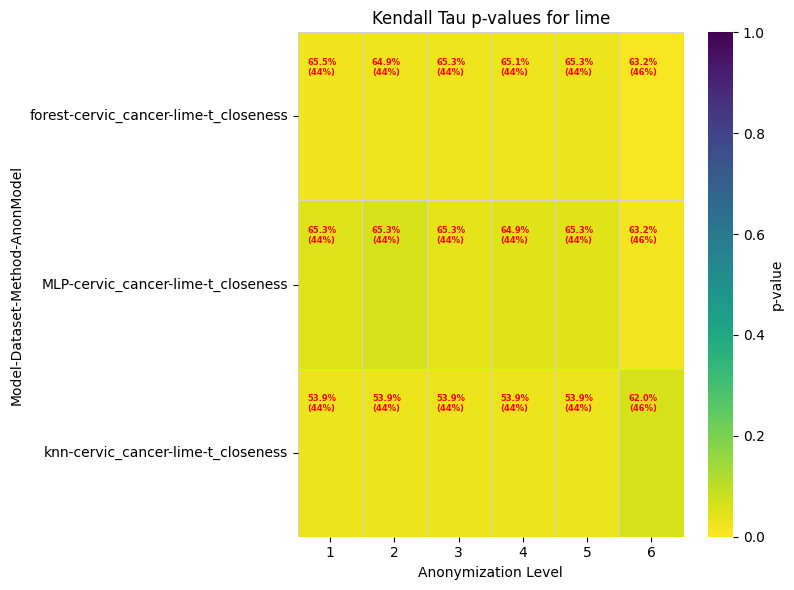

In [6]:
pl.plot_heatmap(datasets=["cervic_cancer"], explanation_methods=['lime'], methods=['t_closeness'])

Indicates instability in MLP. KNN scores better, but the inital ranking of forest gave a higher rank to the featuers that are gone. 

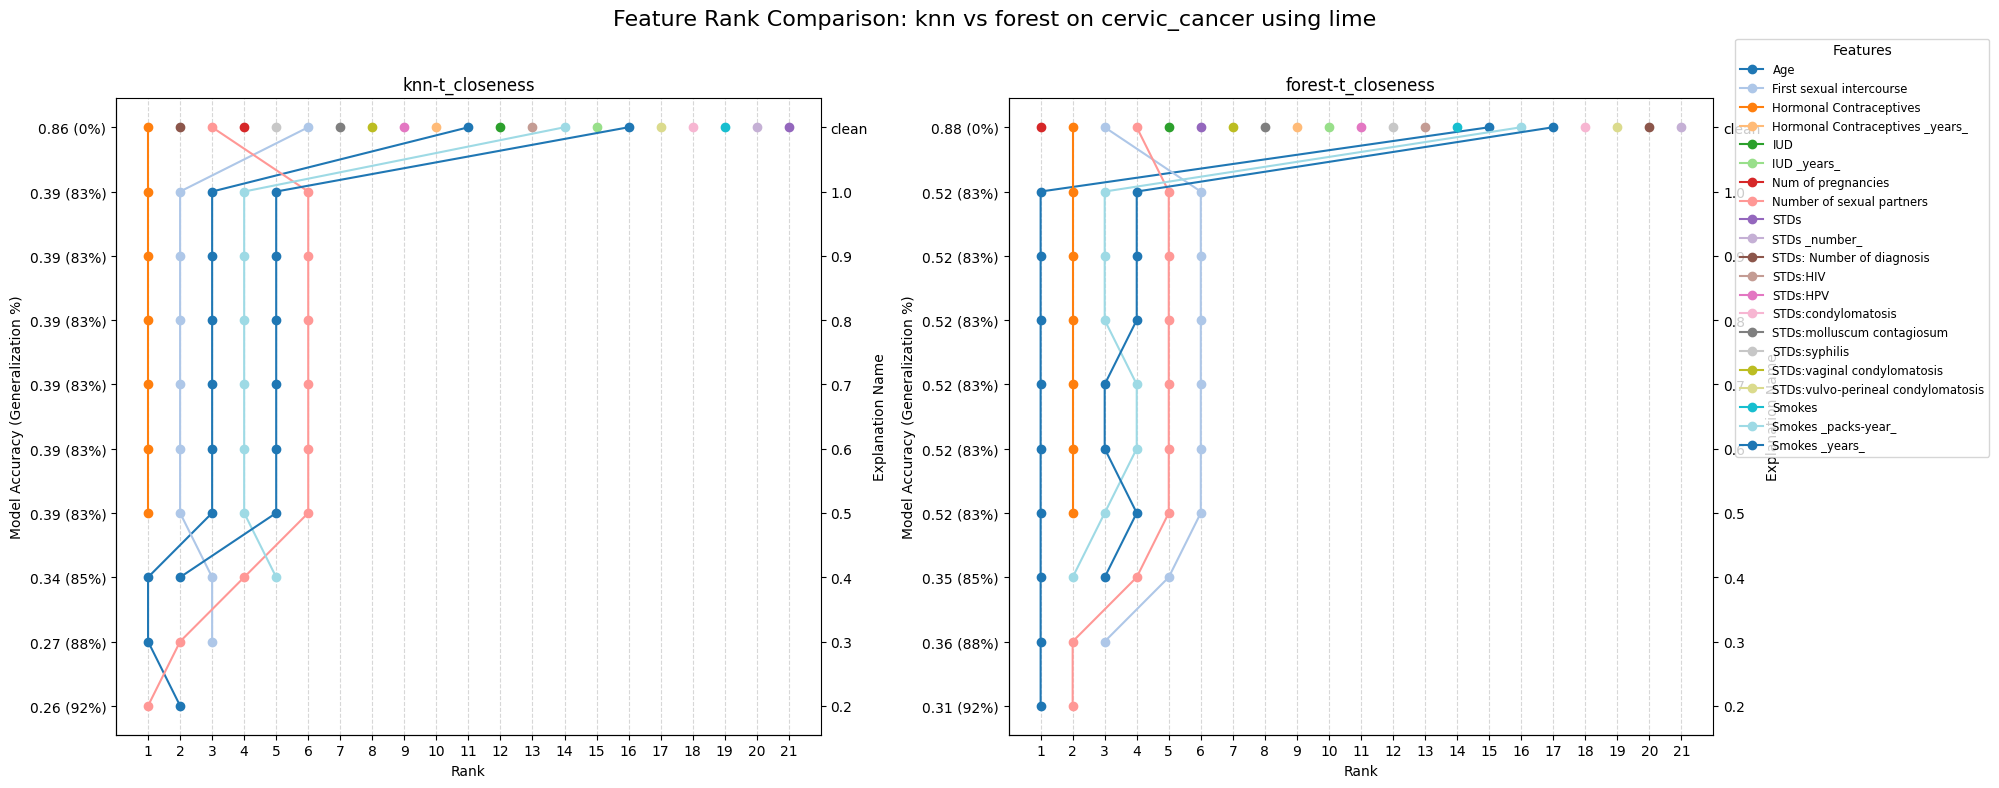

In [12]:
pl.plot_line_compare("knn","forest", "cervic_cancer", "lime", "t_closeness")

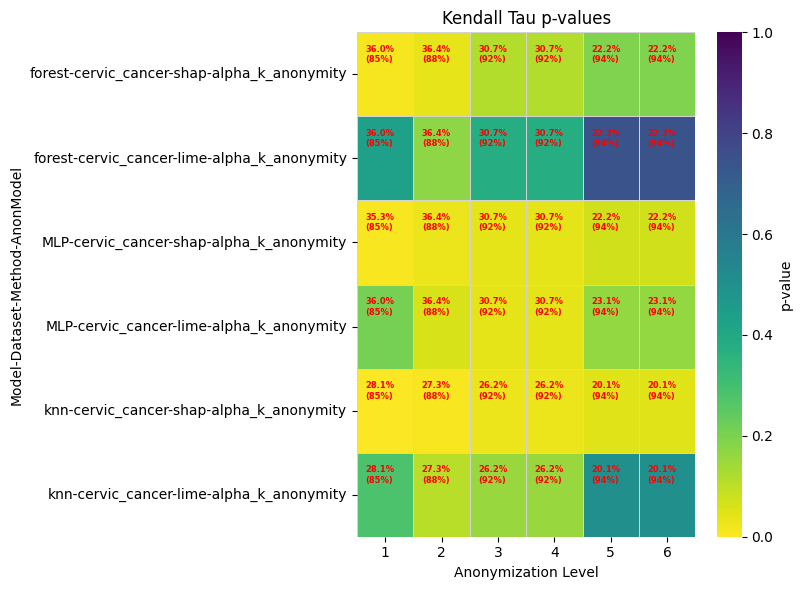

In [14]:
pl.plot_heatmap(datasets=["cervic_cancer"], methods=['alpha_k_anonymity'])

SHAP does a much better job of producing ranks that are consistent with the initial rankings. It does so across models. The exact same is not shown in the usa_house dataset. Here the featuers just happens to be the one that has not been removed.

# Adult

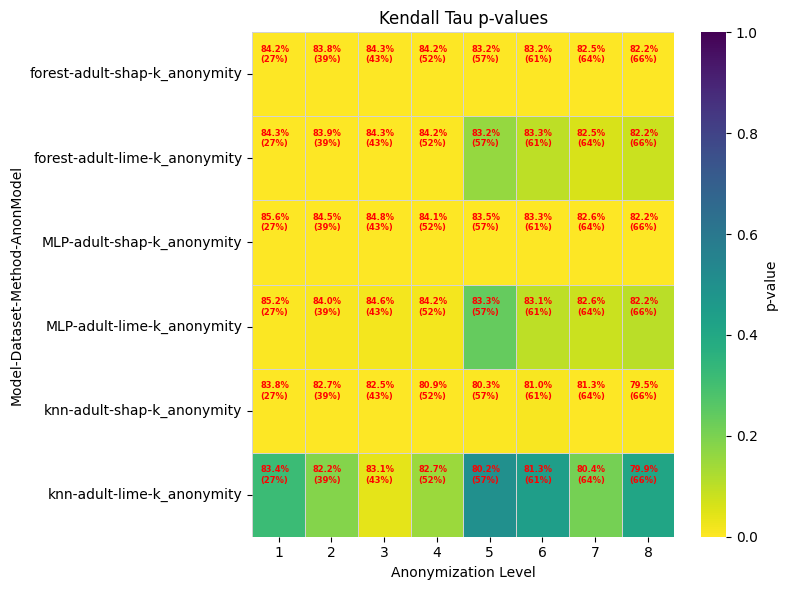

In [18]:
pl.plot_heatmap(datasets=["adult"], methods=["k_anonymity"])#, 't_closeness'])

We again see that knn can also produce slighly unstable lime rankings. However, this instability is not because the same dataset produces different rankings. Here the dataset is generalized slighly at each level so it is actually different. knn is just sensitive to these hierarchy changes. Be careful or the high score though. The dataset is quite imballanced (75 vs 25). If all suppressed instances are the target class, then always guessing majority class is a good idea. 

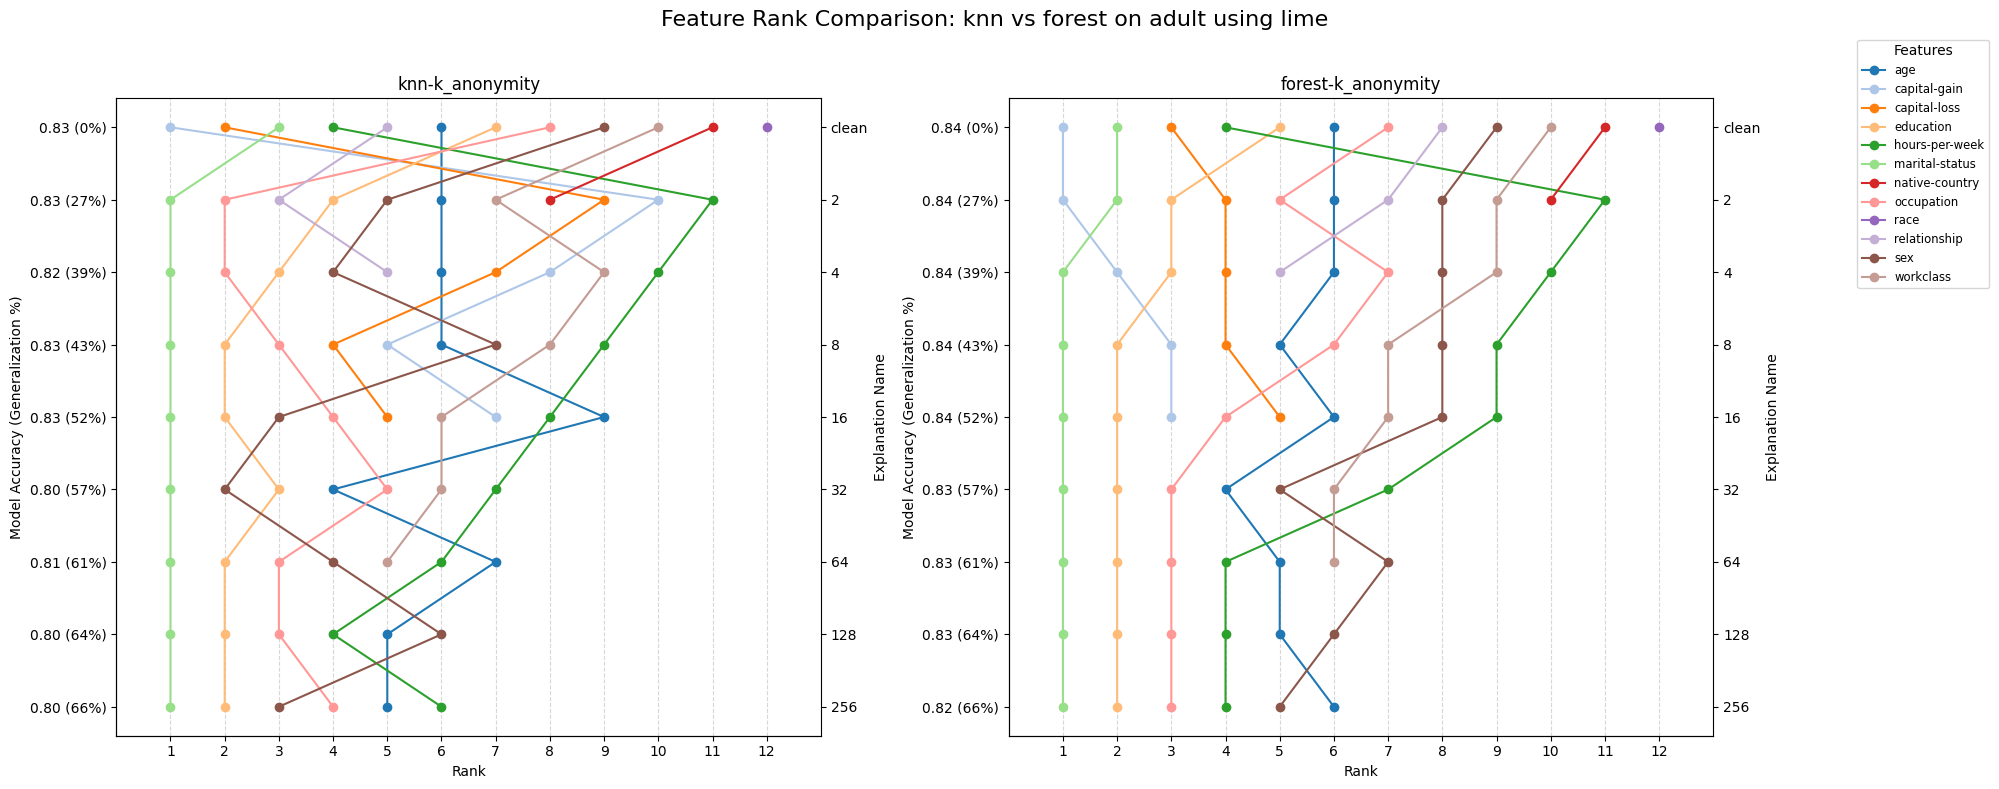

In [19]:
pl.plot_line_compare("knn","forest","adult","lime", "k_anonymity")

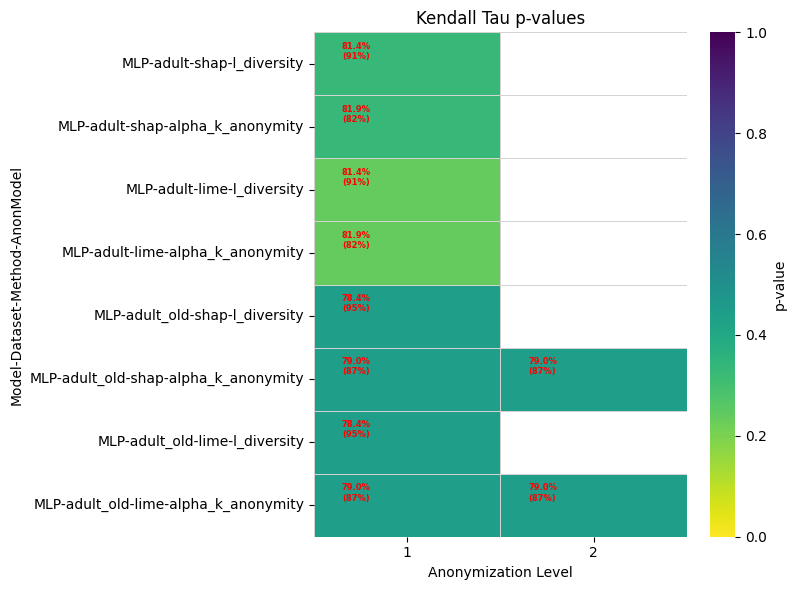

In [21]:
pl.plot_heatmap(classifiers=["MLP"], datasets=["adult", "adult_old"], methods=['l_diversity', 'alpha_k_anonymity'])

It is a binary target class so l-diversity can only be 2. A bit sad that alpha-k-anonymity could not be anonymized to more levels  
Again, we see choice of hiearchy has an effect. On accuracy, explainability and model cireteria.

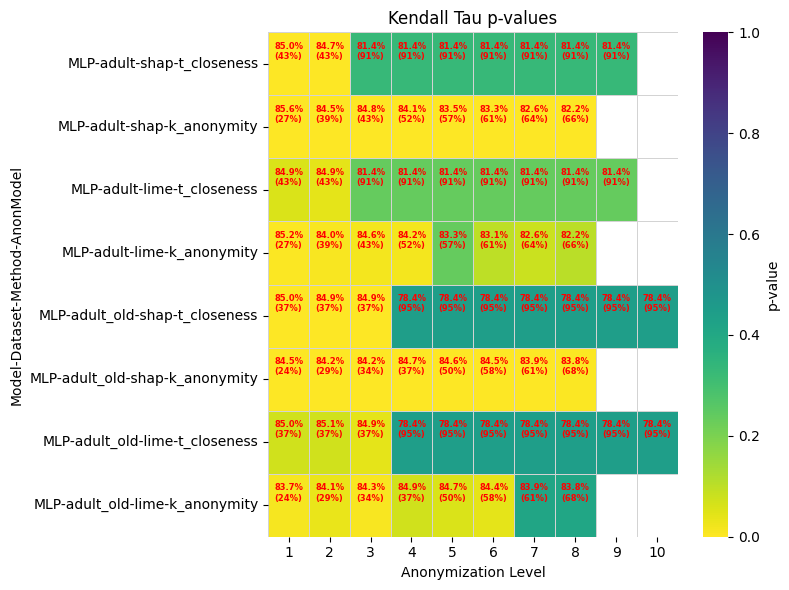

In [22]:
pl.plot_heatmap(classifiers=["MLP"], datasets=["adult", "adult_old"], methods=['k_anonymity', 't_closeness'])

Note, here MLP is actually very stable! This is also the biggest dataset, so it has had more points to be trained on. Maybe, the dataset is spaced out differently in the sapce and in the adult dataset it is just better at describing the points. 

# SHAP Producing rankings more consistent with the original

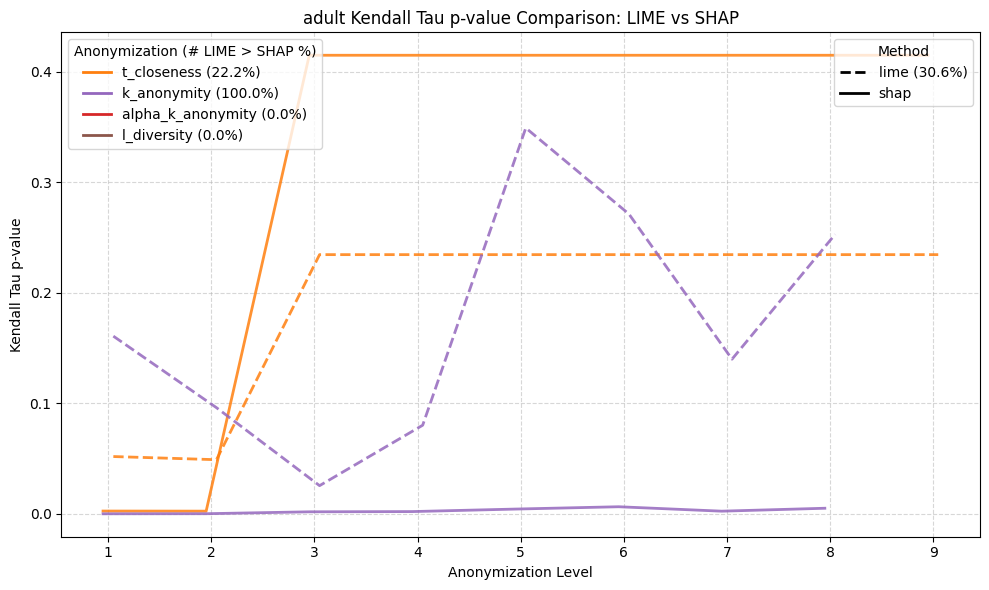

In [25]:
pl.plot_consistency(
    "adult"
)

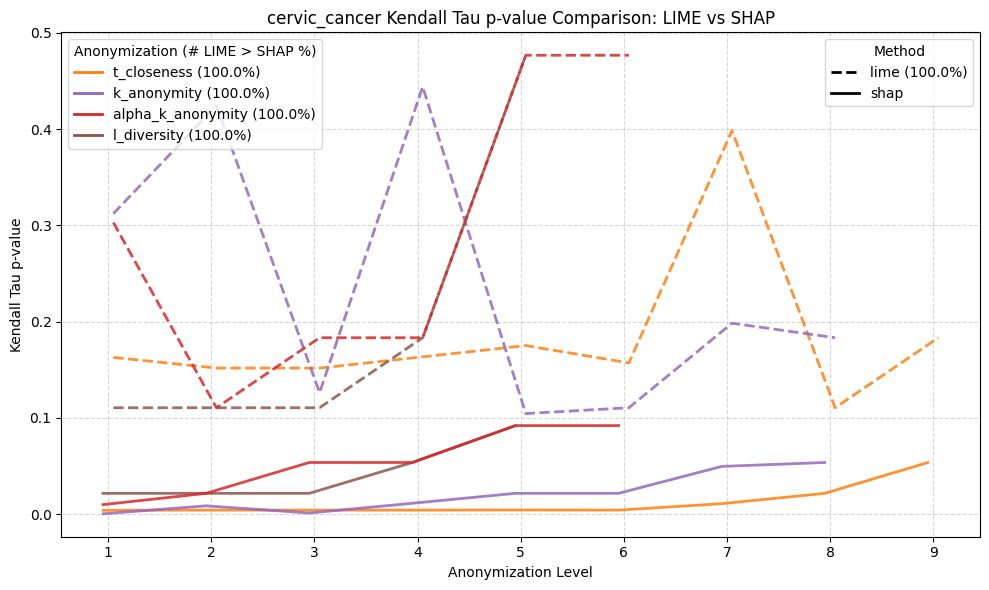

In [26]:
pl.plot_consistency(
    "cervic_cancer"
)

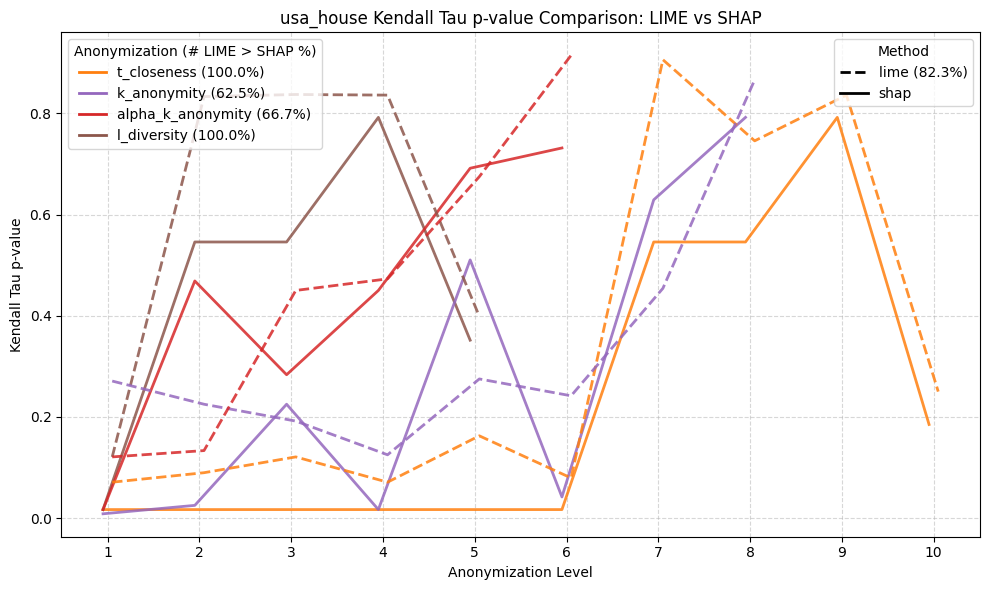

In [27]:
pl.plot_consistency(
    "usa_house"
)

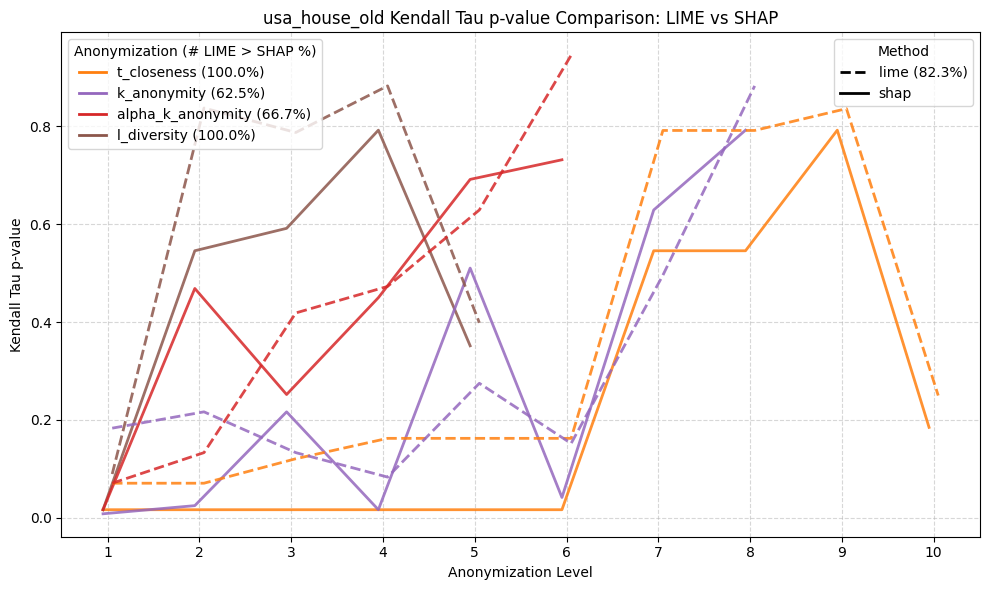

In [28]:
pl.plot_consistency(
    "usa_house_old"
)

While changing the hierarchy of the usa_house dataset had an affect on the actual p-values given to the different anonymized models, it did not change the relationship between lime and shap, aka it did not change the amount of times that LIME produced a more consistent ranking than SHAP

Generally speaking, SHAP produces more consistent rankings than LIME. By consistency, we mean that the rankings produced by SHAP for different anonymized datasets tend to have a lower pvalue than those produced by LIME, i.e. there is generally more statistically evidence for rejecting the null-hypothesis when considering LIME, that is SHAP has 

# Show instability

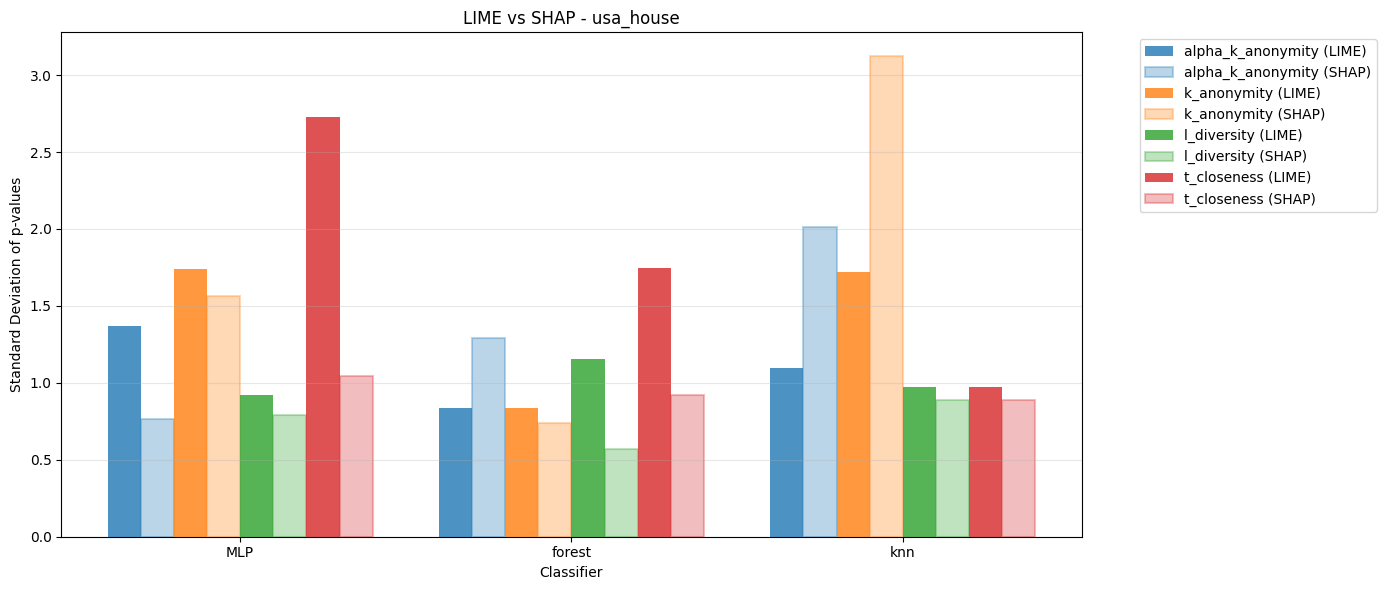

In [3]:
pl.plot_histogram("usa_house")

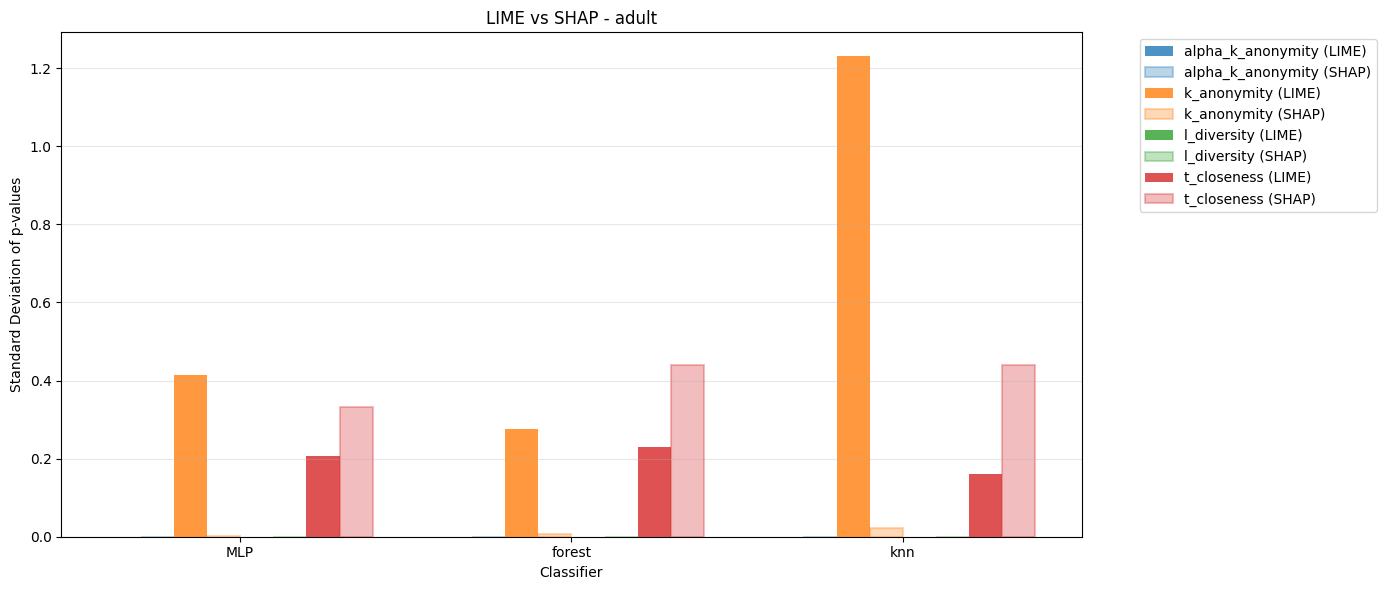

In [4]:
pl.plot_histogram("adult")

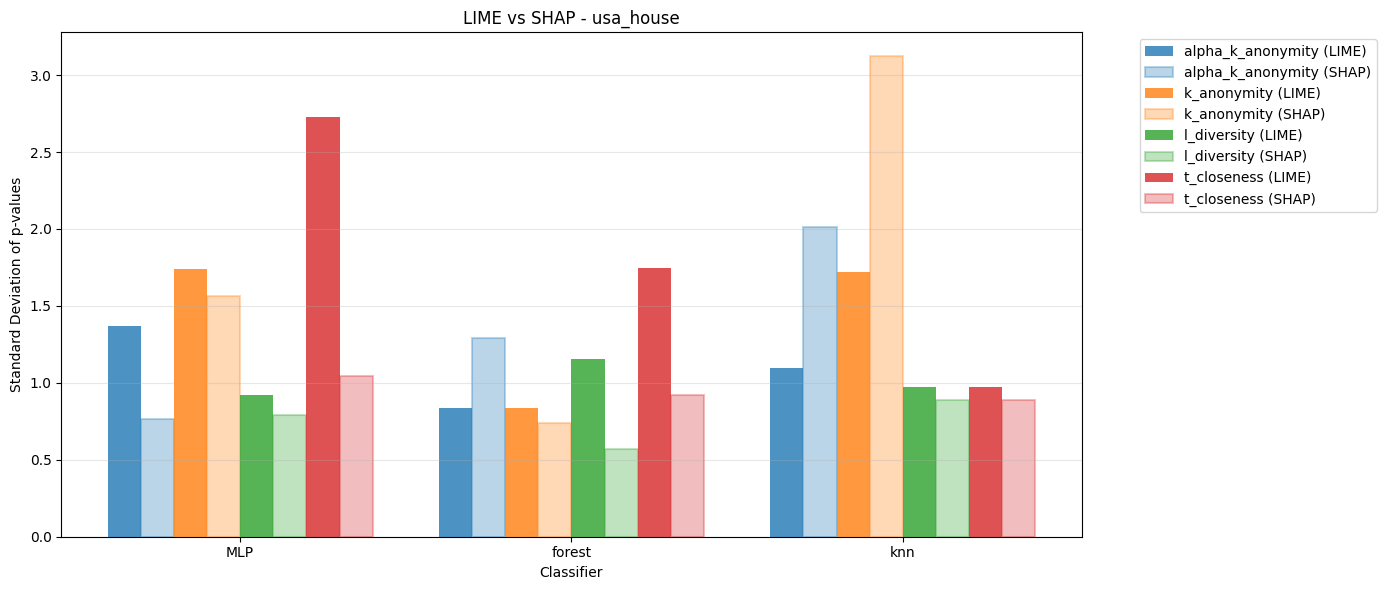

In [5]:
pl.plot_histogram("usa_house")